# To run the code below you need the following files for a single day of data. (updated 1/13/2026, Leslie Sibener)
#
## 1. outputs from kilosort
    # cluster_group.tsv
    # ops.npy
    # spike_clusters.npy
    # spike_times.npy
## 2. matlab behavior data 
    # something like NPX3_P1_2025-11-17_15_51_analyzed.mat
## 3. onebox digital output file that has the timestamps of behavioral events
    # event_times.csv

In [1]:
# IMPORT SETUP STUFF

import sys, os
from pathlib import Path
from datetime import datetime
import csv
import numpy as np
import pandas as pd
import json
import scipy.io
import matplotlib.pyplot as plt
import math

# import all functions ( *) from npix_analysis_functions.py
from npix_analysis_functs import *
import npix_analysis_functs as naf

%load_ext autoreload
%autoreload 2


## Load onebox digital events from CSV

In [2]:
# --- Configuration Section ---

# 1. Define the file path for CSV file.
# IMPORTANT: Replace the example path below with the actual path to CSV file.
#
# Examples:
# Windows: 'C:\\Users\\User\\Documents\\data.csv'
# macOS/Linux: '/Users/User/Documents/data.csv'
#file_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/event_times.csv')
file_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX3_T1/event_times.csv')
file_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX1_T1/event_times.csv')

# --- Script Execution ---

try:
    # Check if the file exists before attempting to load
    if not os.path.exists(file_path):
        print(f"🛑 Error: File not found at the specified path:")
        print(f"       -> {file_path}")
        exit() 

    # Load the CSV file into a pandas DataFrame
    # header=0 tells pandas that the first row is the header (column names)
    data = pd.read_csv(file_path, header=0)

    # --- Verification Section ---
    print("\n✅ CSV loaded successfully!")
    
    # Display the first 5 rows of the loaded data
    print("\n--- First 5 rows of the DataFrame ---")
    print(data.head())
    
    # Display a summary of the DataFrame (column types, non-null counts)
    print("\n--- DataFrame Info ---")
    data.info()

except Exception as e:
    print(f"\n❌ An unexpected error occurred during execution: {e}")

# Adjust the last column so that it variables make sense (don't want to use sec_imap0)
data['baseline_start']=data.sec_imap0[0]
data['training_start']=data.sec_imap0[1]
data['offline_start']=data.sec_imap0[2]


✅ CSV loaded successfully!

--- First 5 rows of the DataFrame ---
   puff_onset   cue_onset    rf_onset  lick_onset  cam_start_stop    sec_imap0
0  774.468216  680.843356  686.891761    0.145662     1928.484015     0.000000
1  774.839103  702.359883  708.441981    1.737912     5848.697501   648.289962
2  775.209990  723.996729  730.069092    2.440053             NaN  1924.963531
3  775.580877  745.573548  751.611492    3.355836             NaN  5842.947149
4  817.171371  767.511123  795.083877    3.578223             NaN          NaN

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   puff_onset      60 non-null     float64
 1   cue_onset       55 non-null     float64
 2   rf_onset        40 non-null     float64
 3   lick_onset      1362 non-null   float64
 4   cam_start_stop  2 non-null      float64
 5   sec_imap0

# Load matlab data

In [ ]:
# Load the .mat file (replace 'file.mat' with file name)

#matfile_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX3_P1_2025-11-17_15_51_analyzed.mat')
#matfile_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX3_T1/NPX3_T1_2025-11-18_16_24_analyzed.mat')
matfile_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX1_T1/NPX1_T1_2025-11-18_11_34_analyzed.mat')

mat_contents = scipy.io.loadmat(matfile_path)

# This 'squeezes' out all the single-dimensional layers (like [1, 1, 36])

raw_trials=mat_contents['trial_list']
# Convert to a simple list or array
flat_trials= raw_trials.item()[0]
trial_list=flat_trials.flatten().tolist()

/opt/anaconda3/envs/npix_env/lib/python3.14/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [ ]:
# check out what variables are in the matlab file
print(mat_contents.keys())

## Load npix data (kilosort output)

In [4]:
# --- Configuration ---
data_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing') # Update this path
data_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX3_T1') # Update this path
data_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX3_T1_HC') # Update this path
data_path = Path('/Volumes/memoryShare/Leslie/data/neuropixels/TTL_Testing/NPX1_T1') # Update this path


ops = np.load(data_path / 'ops.npy', allow_pickle=True).item()
fs = ops['fs']
time_range = [0, 10]  # Time window to plot (in seconds)

spike_times = np.load(data_path / 'spike_times.npy').flatten()
spike_clusters = np.load(data_path / 'spike_clusters.npy').flatten()
    
    # 2. Load cluster metadata to find "good" units
    # cluster_info.tsv contains the "group" label (good, mua, noise)
cluster_info = pd.read_csv(data_path / 'cluster_group.tsv', sep='\t')
good_unit_ids = cluster_info[cluster_info['KSLabel'] == 'good']['cluster_id'].values

In [ ]:
plot_good_units(data_path,spike_times, spike_clusters, cluster_info, time_range, fs)

In [ ]:
# random just plot at the window folling first cue onset
start=data.cue_onset[0]
stop=start + 5
time_range = [start, stop]  # Time window to plot (in seconds)
plot_good_units(data_path,spike_times, spike_clusters, cluster_info, time_range, fs)

## Combine neural and behavior data below! 
## Will create PSTHs for all context types, licks, and puffs

In [5]:
# 1) PREPROCESS EVENT TIMESTAMPS in data PD
cue_clean=data.cue_onset.dropna() # clears out all the nans in empty rows
puff_clean=data.puff_onset.dropna()
rf_clean=data.puff_onset.dropna()
of_cam_clean=data.cam_start_stop.dropna()
catgt_change_clean=data.sec_imap0.dropna()
lick_clean=data['lick_onset'].dropna()

data['cue_clean']=cue_clean
data['puff_clean']=puff_clean
data['rf_clean']=rf_clean
data['of_cam_clean']=of_cam_clean
data['catgt_change_clean']=catgt_change_clean


# 2) pull out the index of trials
rew1_indices = [index for index, value in enumerate(trial_list) if value == 1]
rew2_indices = [index for index, value in enumerate(trial_list) if value == 2]
fear_indices = [index for index, value in enumerate(trial_list) if value == 3]

# 3. Take only the good spiking cells from the raw spiking data
is_good_spike = np.isin(spike_clusters, good_unit_ids)
good_spike_times = spike_times[is_good_spike] / fs  # Convert samples to seconds
good_spike_clusters = spike_clusters[is_good_spike]


## Calculate and organize data into context PSTHs

In [6]:
# 4) Create trial average reponses per neuron, for all 3 trial types

# --- Parameters ---
entire_trial_s=5+6+10 # cue zone 5s, RF zone 6s, ITI 10s
window = [-1.0, entire_trial_s]  # 1s before cue, 2s after (in seconds)
bin_size = 0.1       # 100ms bins for the average PSTH

# 1 = rew1, 2 = rew2, 3 = fear
type_map = {1: 'rew1', 2: 'rew2', 3: 'fear'}

# Generate the data
all_data = organize_neural_data(good_spike_times, good_spike_clusters, cue_clean, trial_list, window, bin_size)

# Get all unit names and sort them numerically (so Unit_2 comes before Unit_10)
all_unit_names = sorted(all_data['fear'].keys(), key=lambda x: int(x.split('_')[1]))

# 2. "Push" the variable into the module's brain
naf.all_unit_names = all_unit_names

print(f"Mapped {len(all_unit_names)} units. You can now use index 0 to {len(all_unit_names)-1}")

Processing 30 trials for: rew1
Processing 10 trials for: rew2
Processing 15 trials for: fear
Mapped 75 units. You can now use index 0 to 74


## Add lick PSTH

In [7]:
# ADD LICK PSTH DATA TO ALL_DATA
window_small = [-1.0, 1]  # 1s before cue, 2s after (in seconds)
bin_size = 0.03       # 20ms bins for the average PSTH

# Run the update
all_data = add_lick_data(all_data, lick_clean, good_spike_times, good_spike_clusters, window_small, bin_size)

Processing licks for 75 units...
Lick data successfully integrated!


## Add puff PSTH

In [8]:
# ADD Puff PSTH DATA TO ALL_DATA
window_small = [-1.0, 1]  # 1s before cue, 2s after (in seconds)
bin_size = 0.03       # 20ms bins for the average PSTH, typical range is 10-50ms
bins_small = np.arange(window_small[0], window_small[1] + bin_size, bin_size)
bin_centers_small = bins_small[:-1] + bin_size/2

# Run the update
all_data = add_puff_data(all_data, puff_clean, good_spike_times, good_spike_clusters, window_small, bin_size)

Processing puffs for 75 units...
Puff data successfully integrated!


## Plot PSTH for each context, each cell
## visually screen cells

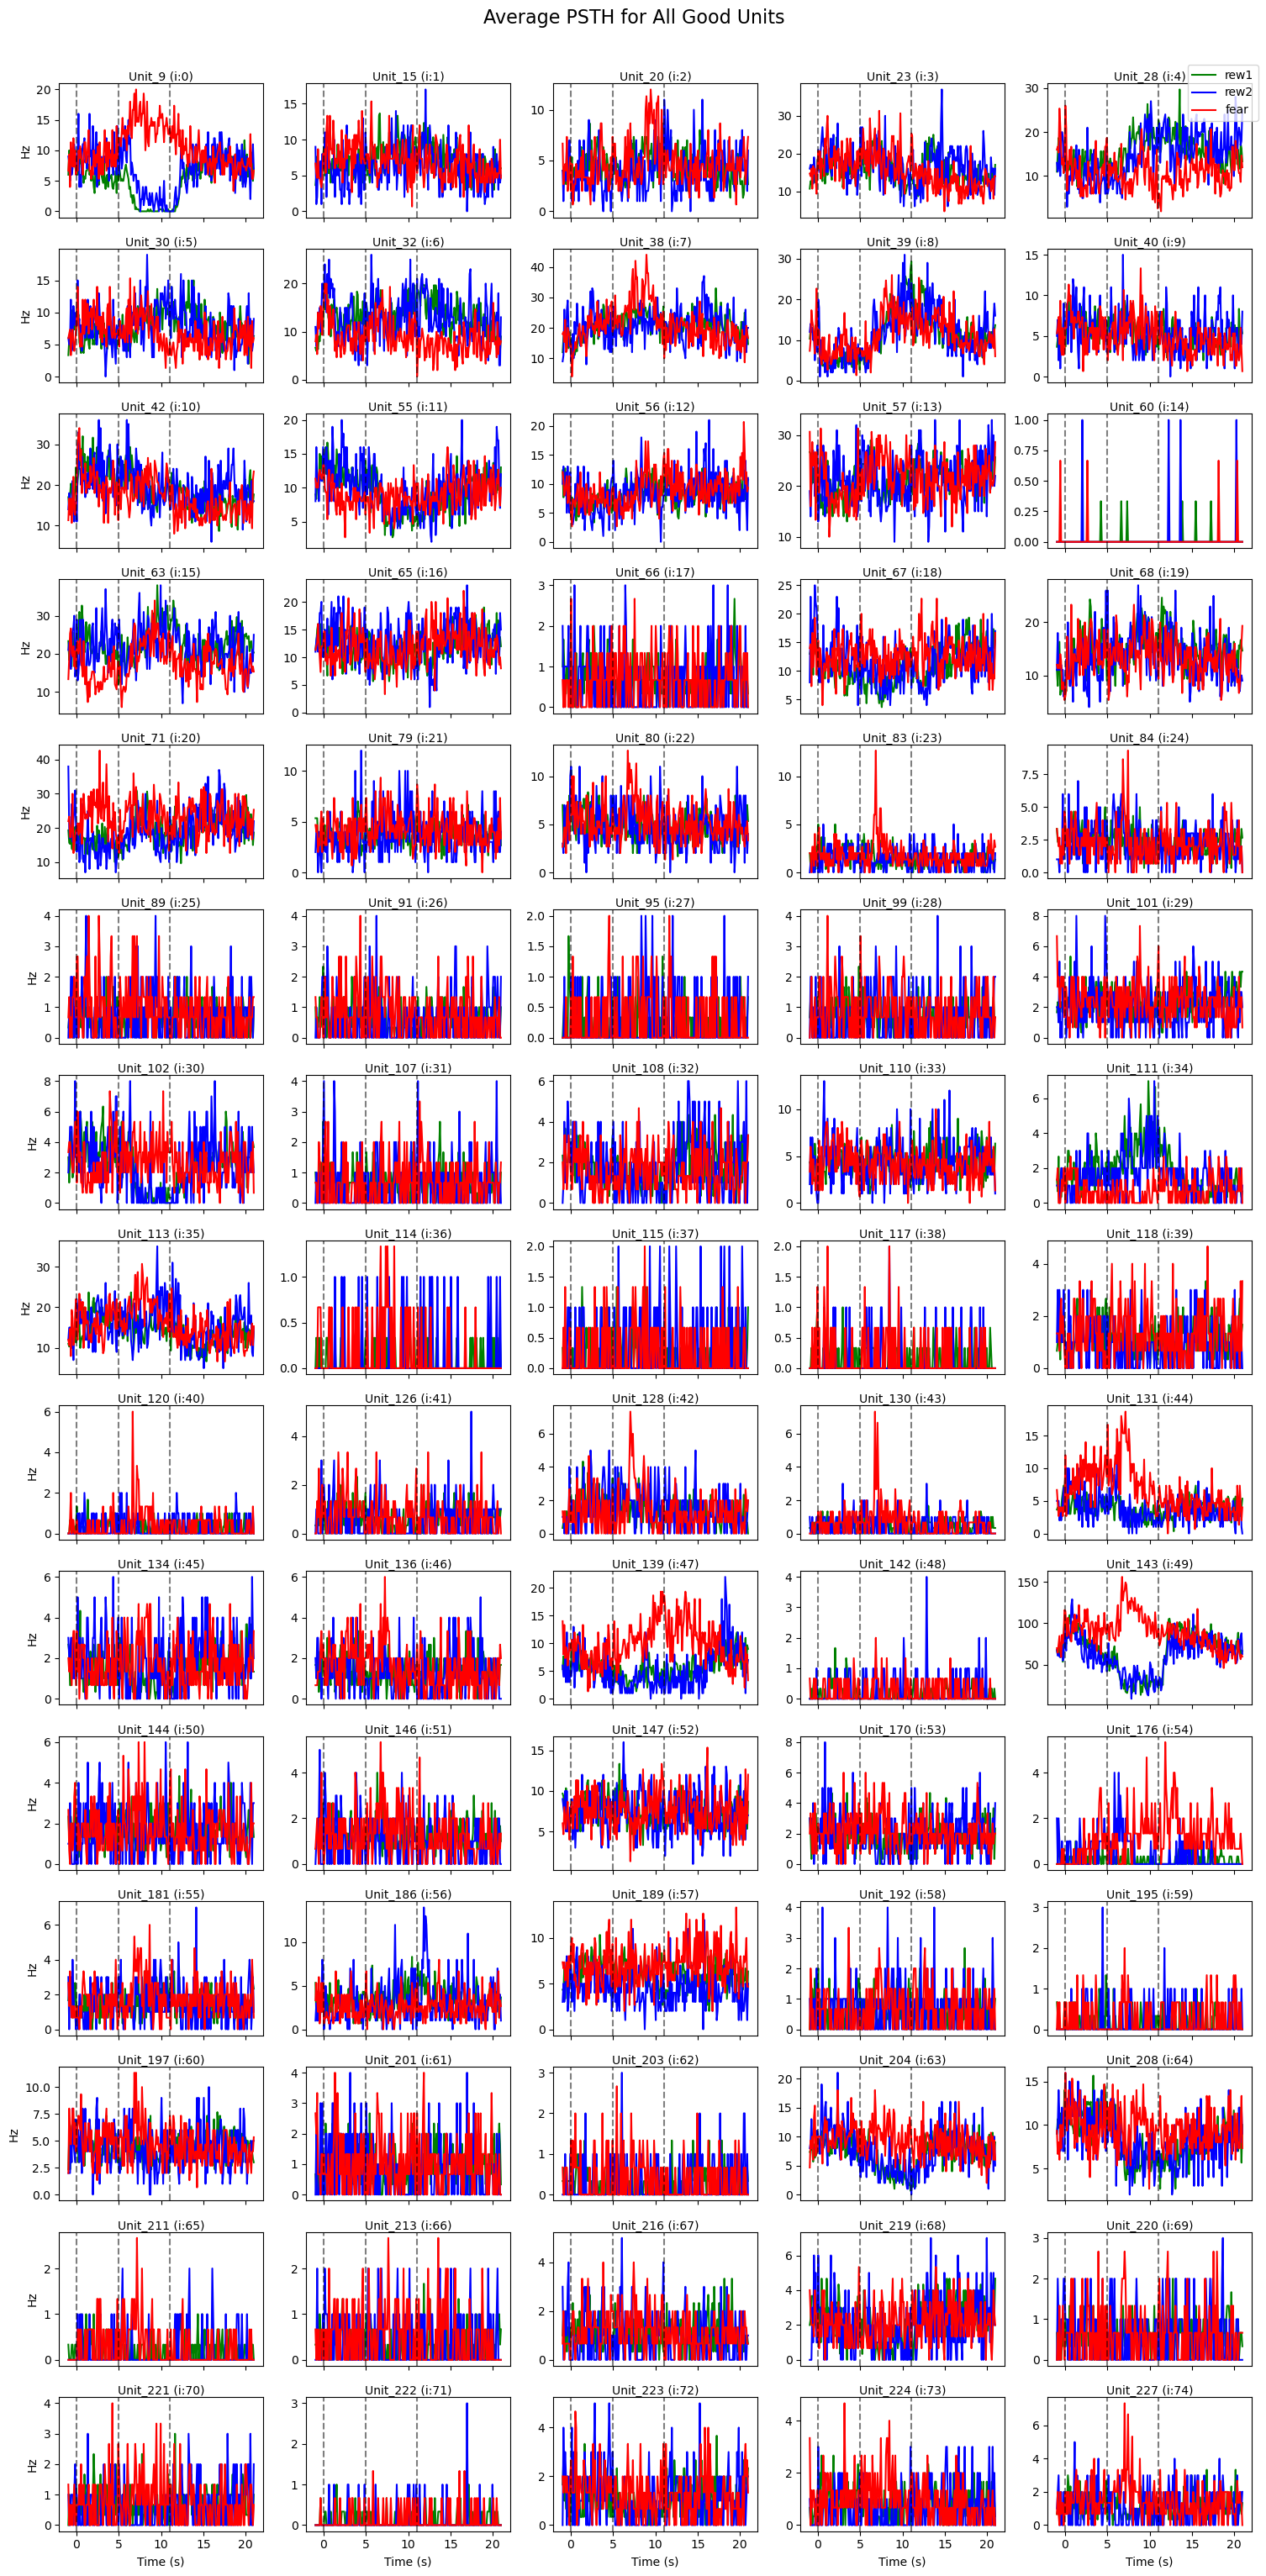

In [18]:
# Plot CONTEXT PSTH for EVERY SINGLE CELL!
plot_all_units_context_grid(all_data)

In [ ]:
# plot heatmap of FR and rater plot for a single unit in x condition
i=0
cond='fear'
plot_unit_trials_heat(all_data, condition=cond, unit_input=i)

# plot PSTH and raster for a single unit in x condition
plot_single_psth_raster(all_data, condition=cond, unit_input=i)

# Plot for ONE CELL PSTH and raster, per context 

Plotting index 44: Unit_131


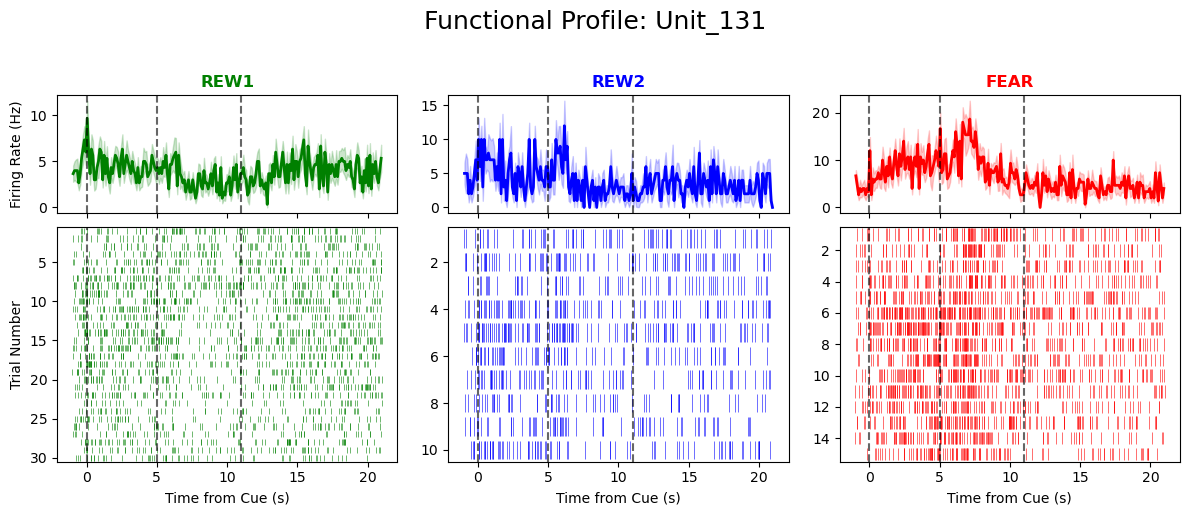

In [31]:
# Run the plot
plot_singleunit_allcontext(all_data, unit_input=44)

# Plot all cell PSTH to lick or grid 
# (can swap out which variable in category)

Plotting 75 units for category: LICKS


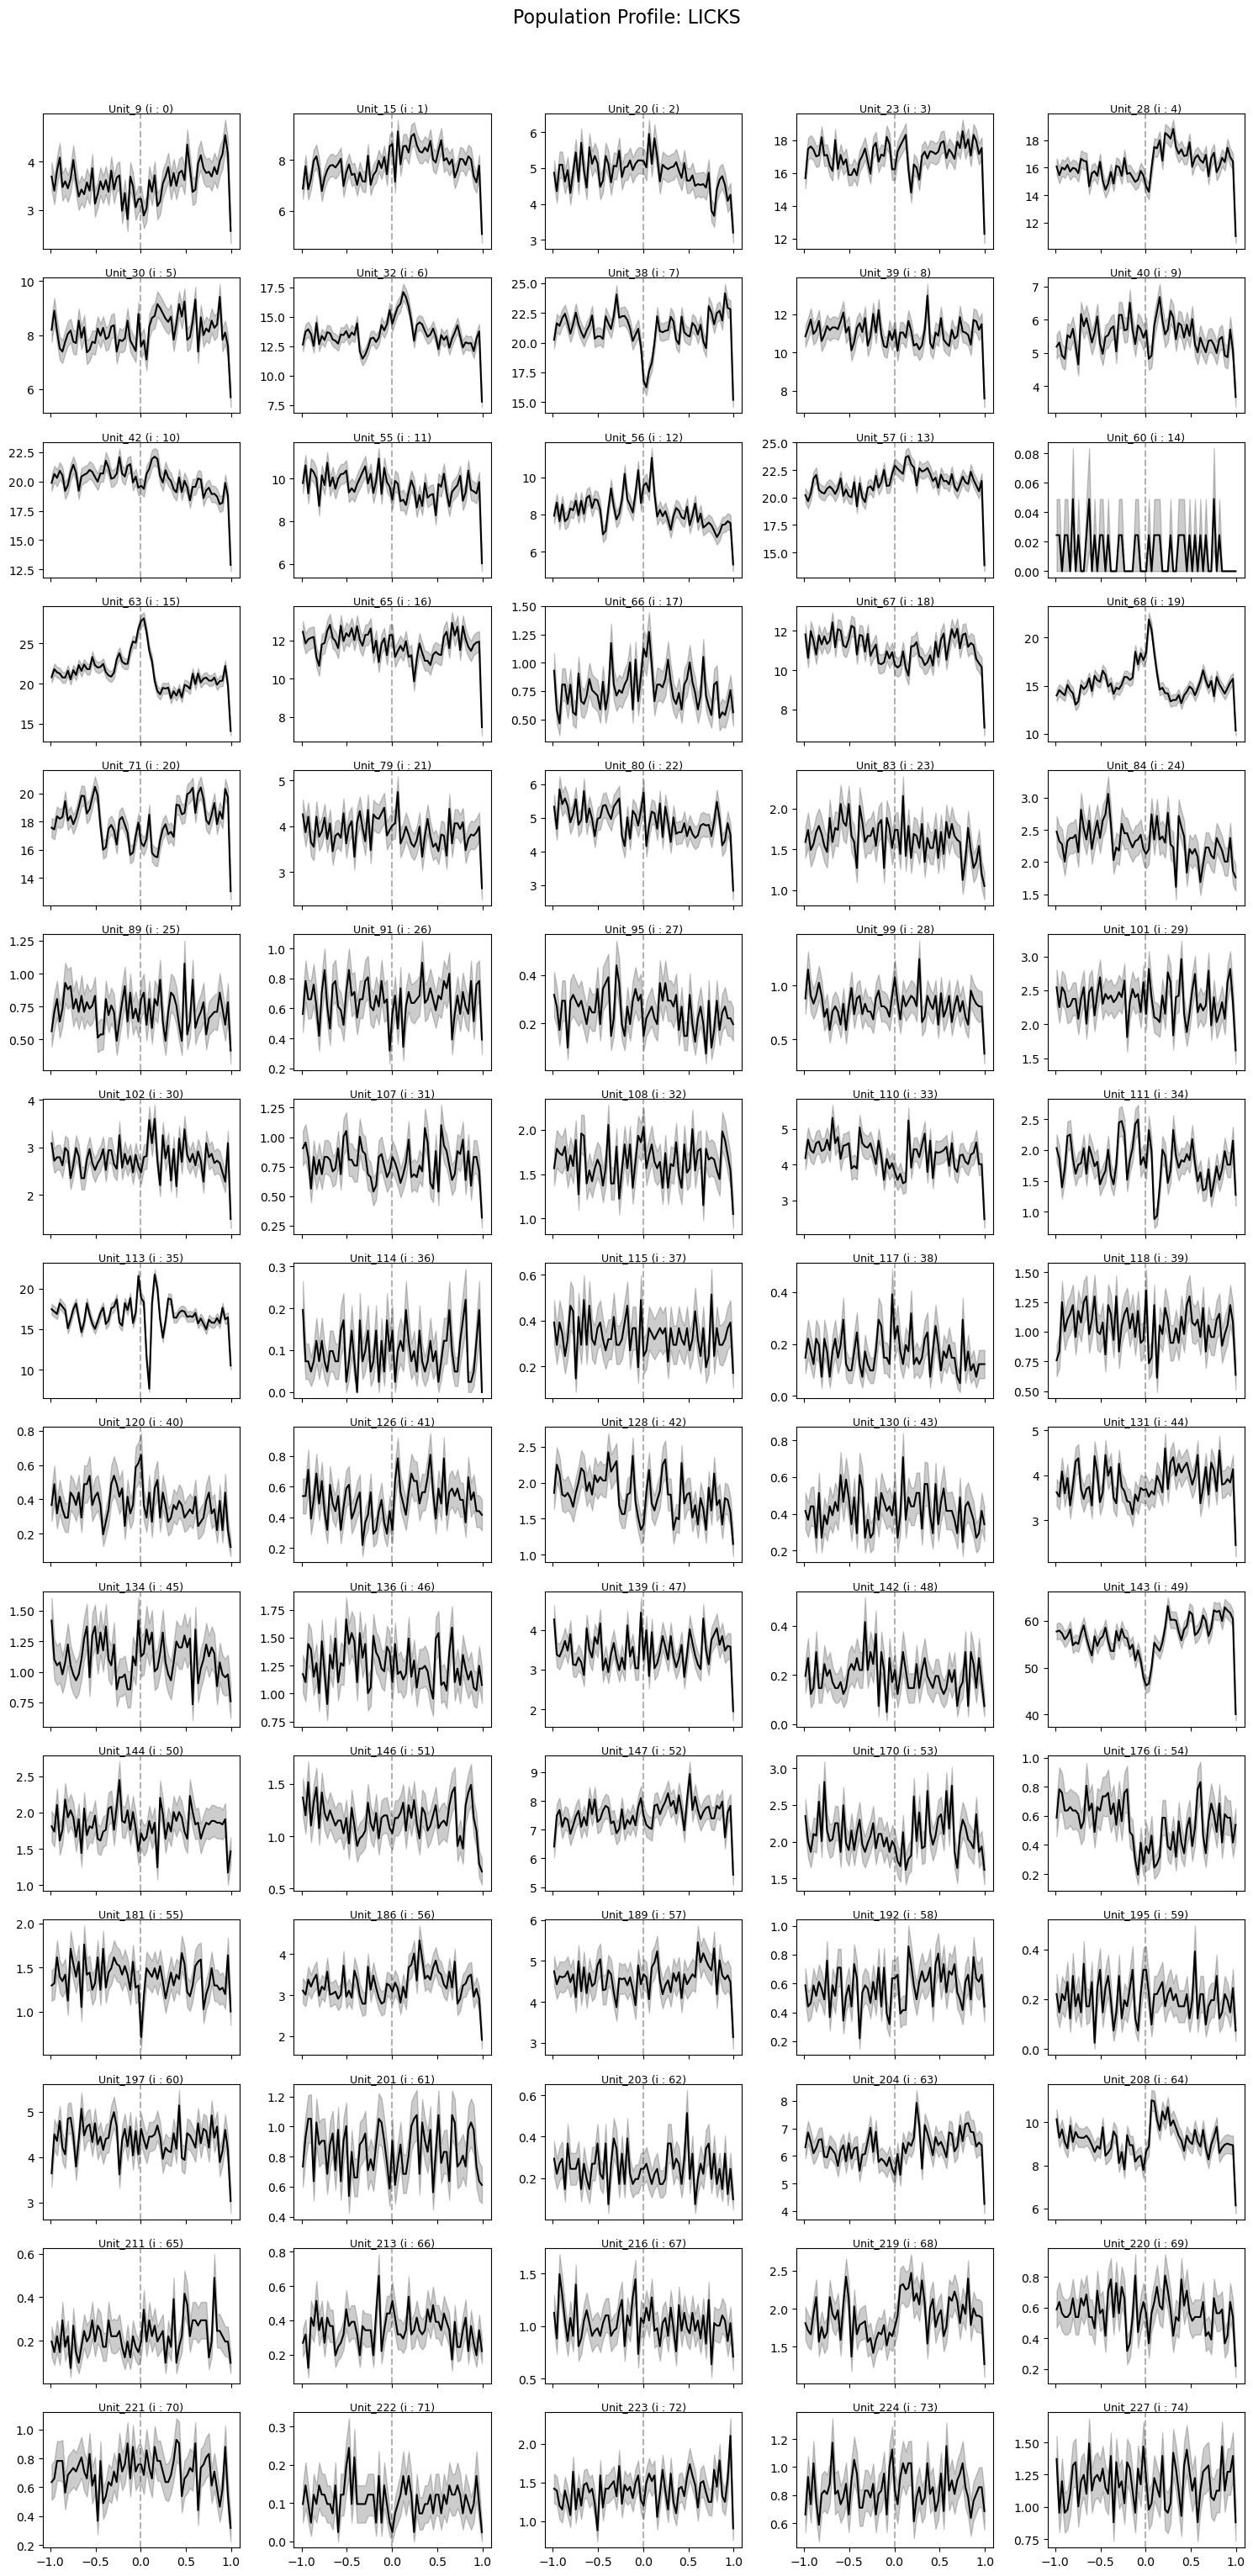

Plotting 75 units for category: PUFFS


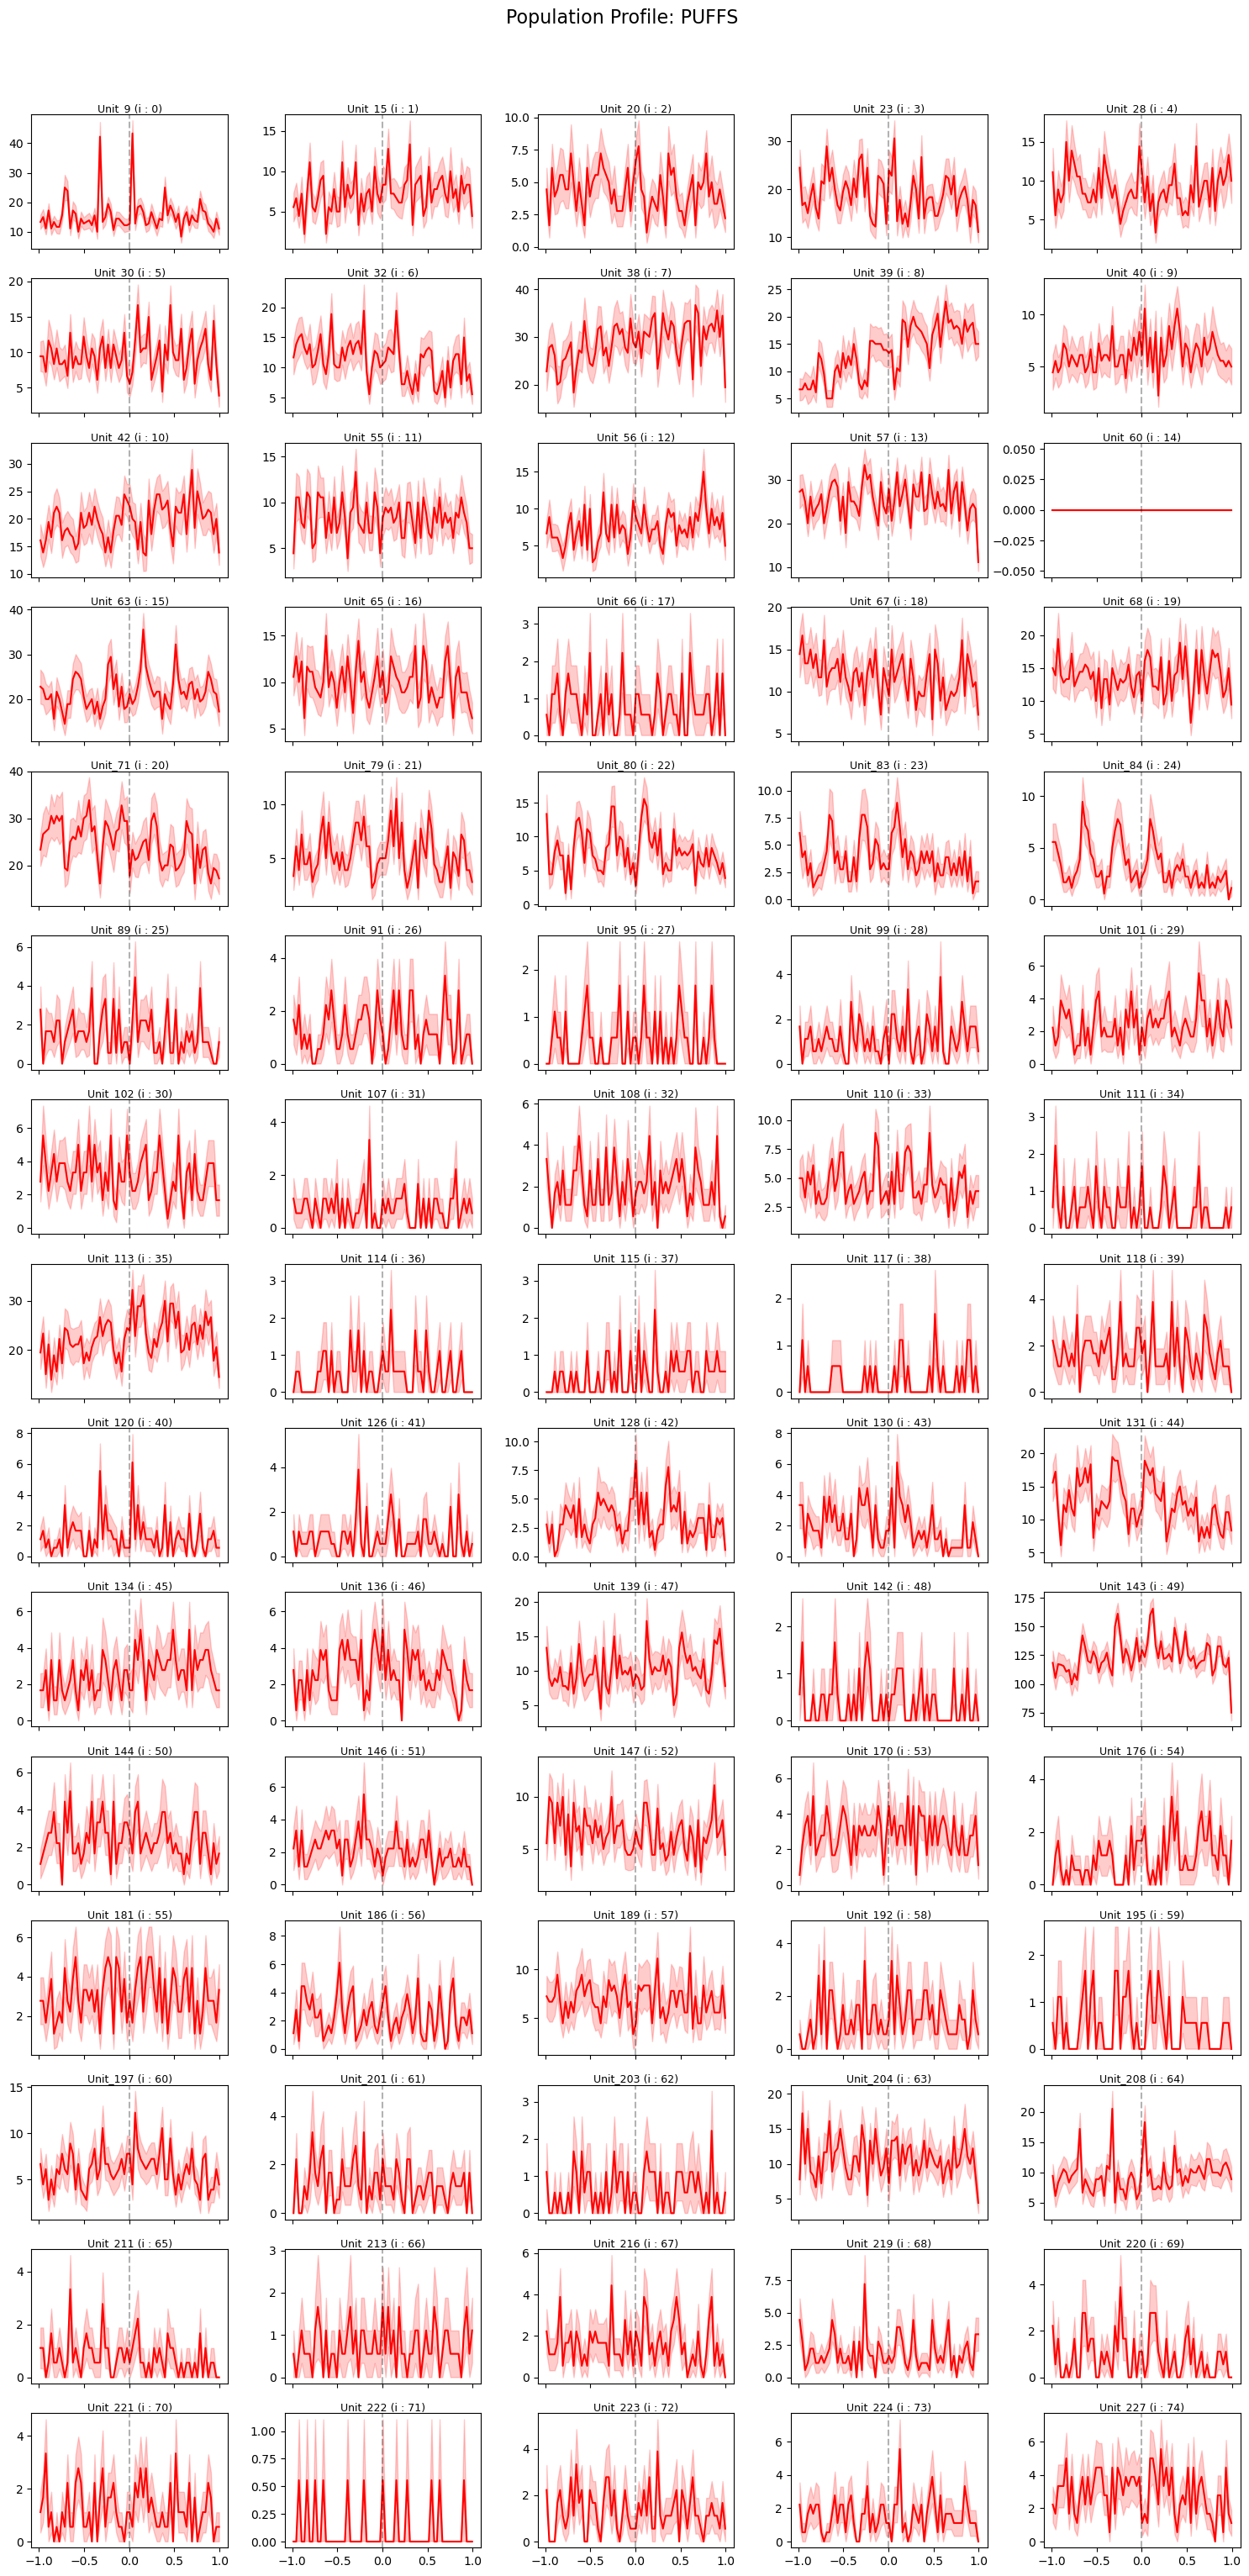

In [13]:
# can do licks, puffs, rew1, rew2, fear as the category
plot_unit_grid(all_data, category='licks', color='black')
plot_unit_grid(all_data, category='puffs', color='red')

# Plot Lick PSTH for SINGLE CELL!

In [ ]:
# Run for the first unit
plot_unit_lick_raster(all_data, unit_input=8, max_licks=500)

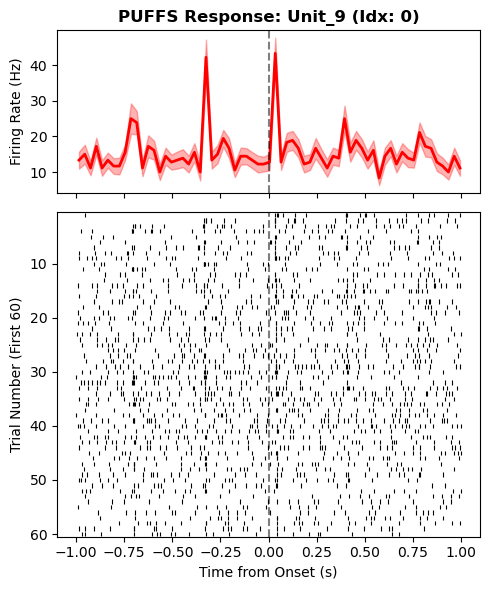

In [26]:
plot_unit_behavior_raster(all_data, category='puffs', unit_input=0, max_trials=500, color='red')

In [ ]:
import pickle
# save the data
with open('organized_neural_data.pkl', 'wb') as f:
    pickle.dump(organized_data, f)